# Starter , Train Test Split and Missing Value Handling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('titanic_data_updated.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
df.shape

print(f"Total potential features :{df.shape[1]}")
print(f"Total sample data :{df.shape[0]}")

Total potential features :12
Total sample data :891


In [8]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
750,751,yes,second,"Wells, Miss. Joan",female,4.0,1,1,29103,23.0000,NaN,S
604,605,yes,first,"Homer, Mr. Harry (""Mr E Haven"")",male,35.0,0,0,111426,26.5500,NaN,C
341,342,yes,first,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
879,880,yes,first,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
515,516,no,first,"Walker, Mr. William Anderson",male,47.0,0,0,36967,34.0208,D46,S
425,426,no,third,"Wiseman, Mr. Phillippe",male,NaN,0,0,A/4. 34244,7.2500,NaN,S
702,703,no,third,"Barbara, Miss. Saiide",female,18.0,0,1,2691,14.4542,NaN,C
492,493,no,first,"Molson, Mr. Harry Markland",male,55.0,0,0,113787,30.5000,C30,S
177,178,no,first,"Isham, Miss. Ann Elizabeth",female,50.0,0,0,PC 17595,28.7125,C49,C
633,634,no,first,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S


## Feature Engineering

Step:
1. If Target column does not have relation, delete those
2. Choose Feature Column and Target Column in separate data frame
3. Train Test Split
4. Missing values handling
5. Outliner (abnormal) detection data finding and cap it in a range or delete it.
6. Encode Categorical Column. Category to Numerical
7. Numerical Column Scaling
8. Feature Creation

In [5]:
### We dont need passenger id, ticket number, name,

In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [10]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,no,third,male,22.0,1,0,7.2500,S
1,yes,first,female,38.0,1,0,71.2833,C
2,yes,third,female,26.0,0,0,7.9250,S
3,yes,first,female,35.0,1,0,53.1000,S
4,no,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,S
887,yes,first,female,19.0,0,0,30.0000,S
888,no,third,female,NaN,1,2,23.4500,S
889,yes,first,male,26.0,0,0,30.0000,C


In [12]:
# missing value

df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [13]:
# Seperate feacture and target column

# Feature: Everything except survive
# Target: Survived

X= df.drop('Survived', axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S
4,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,S
887,first,female,19.0,0,0,30.0000,S
888,third,female,NaN,1,2,23.4500,S
889,first,male,26.0,0,0,30.0000,C


In [15]:
Y= df['Survived']

Y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

## Train Test Split

In [18]:
x_train, x_test, y_train, y_test =train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S
813,third,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,S
270,first,male,NaN,0,0,31.0000,S
860,third,male,41.0,2,0,14.1083,S
435,first,female,14.0,1,2,120.0000,S


In [22]:
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [23]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,NaN,1,1,15.2458,C
439,second,male,31.0,0,0,10.5000,S
840,third,male,20.0,0,0,7.9250,S
720,second,female,6.0,0,1,33.0000,S
39,third,female,14.0,1,0,11.2417,C
...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,S
773,third,male,NaN,0,0,7.2250,C
25,third,female,38.0,1,5,31.3875,S
84,second,female,17.0,0,0,10.5000,S


In [25]:
y_test

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

## Numerical Missing Value Imputation with Pandas

In [27]:
# imputing misssing value

## Deleting the row for missing value if it has only few missing value
## Deleting the colum if it has too many missing value

x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [28]:
x_test.isnull().sum()

Pclass       0
Sex          0
Age         37
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64

In [ ]:
age_mean = x_train['Age'].mean()

x_train['age_mean_imputor']=x_train['Age'].fillna(age_mean)

x_test['age_mean_imputor']=x_test['Age'].fillna(age_mean)


x_train.isnull().sum()

Pclass              0
Sex                 0
Age                 0
SibSp               0
Parch               0
Fare                0
Embarked            2
age_mean_imputor    0
dtype: int64

In [33]:
age_median = x_train['Age'].median()

x_train['age_median_imputor']=x_train['Age'].fillna(age_median)

x_test['age_median_imputor']=x_test['Age'].fillna(age_median)

x_train.isnull().sum()


Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              2
age_mean_imputor      0
age_median_imputor    0
dtype: int64

<Axes: xlabel='age_mean_imputor', ylabel='Density'>

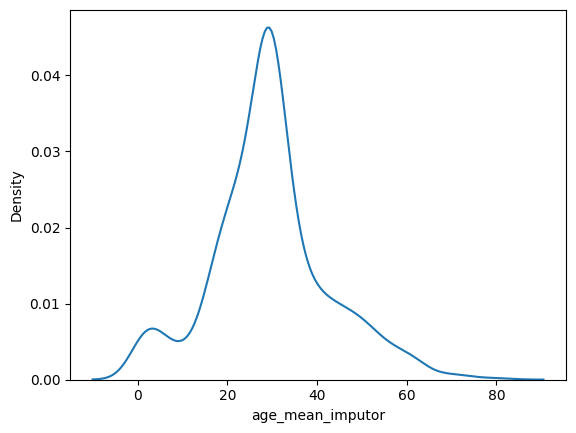

In [34]:
sns.kdeplot(data=x_train, x='age_mean_imputor')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

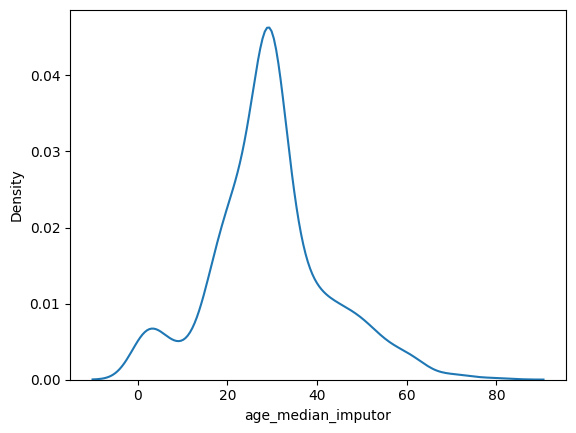

In [35]:
sns.kdeplot(data=x_train, x='age_median_imputor')

## Numerical Missing Values Imputation using Simple Imputer

In [36]:
from sklearn.impute import SimpleImputer

In [37]:
age_imputer = SimpleImputer(missing_values=np.nan , strategy= 'mean')

# 2d data pathabe
age_imputer.fit(x_train[['Age']])

x_train['Age']= age_imputer.transform(x_train[['Age']])

x_train.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              2
age_mean_imputor      0
age_median_imputor    0
dtype: int64

In [38]:
x_train.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              2
age_mean_imputor      0
age_median_imputor    0
dtype: int64

In [40]:
x_train.drop(['age_mean_imputor', 'age_median_imputor'],axis=1,inplace=True)

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.500000,0,0,28.5000,S
733,second,male,23.000000,0,0,13.0000,S
382,third,male,32.000000,0,0,7.9250,S
704,third,male,26.000000,1,0,7.8542,S
813,third,female,6.000000,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,S
270,first,male,29.498846,0,0,31.0000,S
860,third,male,41.000000,2,0,14.1083,S
435,first,female,14.000000,1,2,120.0000,S


In [ ]:
x_test['Age']= age_imputer.transform(x_test[['Age']])

x_test.isnull().sum()

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              0
age_median_imputor    0
dtype: int64

In [45]:
#x_test.drop(['age_median_imputor'],axis=1,inplace=True)

x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,29.498846,1,1,15.2458,C
439,second,male,31.000000,0,0,10.5000,S
840,third,male,20.000000,0,0,7.9250,S
720,second,female,6.000000,0,1,33.0000,S
39,third,female,14.000000,1,0,11.2417,C
...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,S
773,third,male,29.498846,0,0,7.2250,C
25,third,female,38.000000,1,5,31.3875,S
84,second,female,17.000000,0,0,10.5000,S


## Categorical Value Imputation with Mode Value

In [46]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputer.fit(x_train[['Embarked']])

# transform both train and test data

x_train['Embarked']=embarked_imputer.transform(x_train[['Embarked']]).ravel()

x_test['Embarked']=embarked_imputer.transform(x_test[['Embarked']]).ravel()


In [47]:
x_train.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [48]:
x_test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [ ]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='missing')